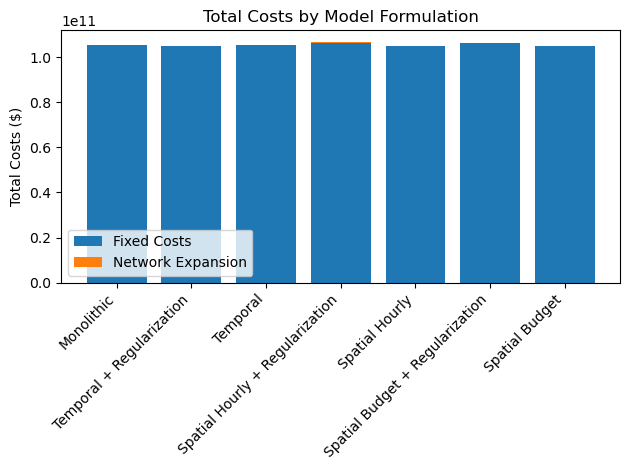

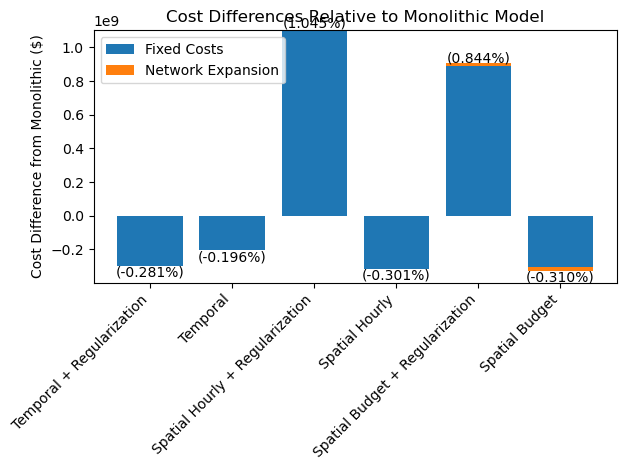

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Read data
# -----------------------
df = pd.read_csv("master_costs.csv")

methods = df["Method"].values
cTotal = df["cTotal"].values
cFix = df["cFix"].values
cNetwork = df["cNetwork"].values

x = np.arange(len(methods))

# -----------------------
# Plot 1: Total Costs (stacked)
# -----------------------
plt.figure()

plt.bar(x, cFix, label="Fixed Costs")
plt.bar(x, cNetwork, bottom=cFix, label="Network Expansion")

plt.xticks(x, methods, rotation=45, ha="right")
plt.ylabel("Total Costs ($)")
plt.title("Total Costs by Model Formulation")
plt.legend()

plt.tight_layout()
plt.show()

# -----------------------
# Plot 2: Differences from Monolithic
# -----------------------
baseline_total = cTotal[0]
baseline_fix = cFix[0]
baseline_network = cNetwork[0]

diff_fix = cFix[1:] - baseline_fix
diff_network = cNetwork[1:] - baseline_network
diff_total = cTotal[1:] - baseline_total
percent_error = diff_total / baseline_total * 100

labels = methods[1:]
x = np.arange(len(labels))

plt.figure()

plt.bar(x, diff_fix, label="Fixed Costs")
plt.bar(x, diff_network, bottom=diff_fix, label="Network Expansion")

# Percent error annotation
for i in range(len(diff_total)):
    plt.text(
        x[i],
        diff_total[i],
        f"({percent_error[i]:.3f}%)",
        ha="center",
        va="bottom" if diff_total[i] >= 0 else "top"
    )

plt.xticks(x, labels, rotation=45, ha="right")
plt.ylabel("Cost Difference from Monolithic ($)")
plt.title("Cost Differences Relative to Monolithic Model")
plt.legend()

plt.tight_layout()
plt.savefig("cost_differences.png")


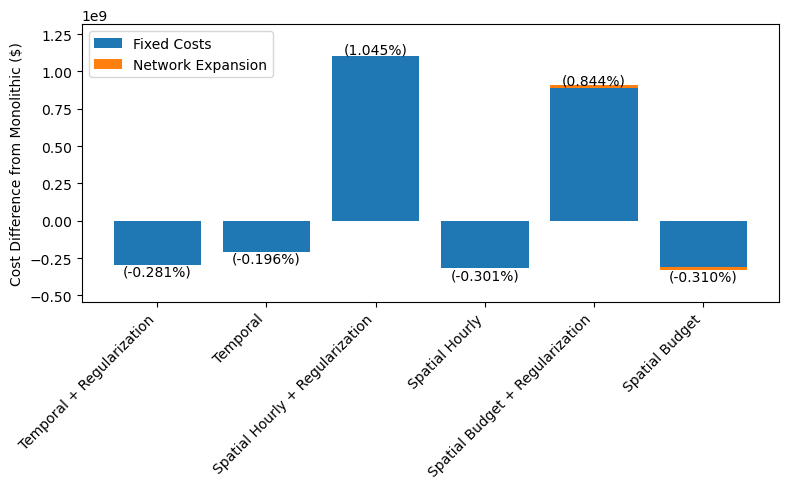

In [6]:
# -----------------------
# Plot 2: Differences from Monolithic (with padding)
# -----------------------
baseline_total = cTotal[0]
baseline_fix = cFix[0]
baseline_network = cNetwork[0]

diff_fix = cFix[1:] - baseline_fix
diff_network = cNetwork[1:] - baseline_network
diff_total = cTotal[1:] - baseline_total
percent_error = diff_total / baseline_total * 100

labels = methods[1:]
x = np.arange(len(labels))

plt.figure(figsize=(8, 5))  # <-- makes plot bigger overall

plt.bar(x, diff_fix, label="Fixed Costs")
plt.bar(x, diff_network, bottom=diff_fix, label="Network Expansion")

# Annotate percent error
for i in range(len(diff_total)):
    plt.text(
        x[i],
        diff_total[i],
        f"({percent_error[i]:.3f}%)",
        ha="center",
        va="bottom" if diff_total[i] >= 0 else "top"
    )

# --- Add vertical padding ---
y_min = min(0, diff_total.min())
y_max = max(0, diff_total.max())

padding = 0.15 * (y_max - y_min)
plt.ylim(y_min - padding, y_max + padding)

plt.xticks(x, labels, rotation=45, ha="right")
plt.ylabel("Cost Difference from Monolithic ($)")
#plt.title("Cost Differences Relative to Monolithic Model")
plt.legend(loc="upper left")

plt.tight_layout()
plt.savefig("cost_differences.png")



Network

[ 2.38634532e-04  2.38634532e-04  2.38634532e-04  2.38634532e-04
 -3.09432314e+01 -3.09432314e+01]


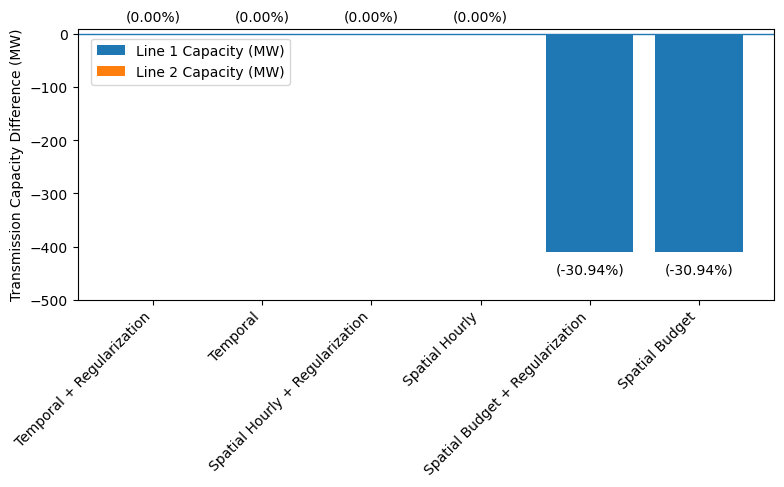

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Read data
# -----------------------
df = pd.read_csv("master_network_expansion.csv")
for col in ["Line 1", "Line 2"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.dropna(subset=["Line 1", "Line 2"])

methods = df["Method"].values
line1 = df["Line 1"].values
line2 = df["Line 2"].values

total_capacity = line1 + line2

# -----------------------
# Baseline (Monolithic)
# -----------------------
baseline_total = total_capacity[0]
baseline_line1 = line1[0]
baseline_line2 = line2[0]

# Differences (exclude monolithic)
diff_line1 = line1[1:] - baseline_line1
diff_line2 = line2[1:] - baseline_line2
diff_total = total_capacity[1:] - baseline_total

percent_error = 100 * diff_total / baseline_total

labels = methods[1:]
x = np.arange(len(labels))
print(percent_error)

# -----------------------
# Plot
# -----------------------
plt.figure(figsize=(8, 5))

plt.bar(x, diff_line1, label="Line 1 Capacity (MW)")
plt.bar(x, diff_line2, bottom=diff_line1, label="Line 2 Capacity (MW)")

# Zero line
plt.axhline(0, linewidth=1)

# -----------------------
# Annotations (percent change)
# -----------------------
y_extent = max(abs(diff_total.min()), abs(diff_total.max()))
offset = 0.05 * y_extent

for i in range(len(diff_total)):
    plt.text(
        x[i],
        diff_total[i] + (offset if diff_total[i] >= 0 else -offset),
        f"({percent_error[i]:.2f}%)",
        ha="center",
        va="bottom" if diff_total[i] >= 0 else "top"
    )

# -----------------------
# Axes & layout
# -----------------------
plt.ylim(-500, 10)
plt.xticks(x, labels, rotation=45, ha="right")
plt.ylabel("Transmission Capacity Difference (MW)")
plt.legend(loc="upper left", bbox_to_anchor=(0.01, 0.99))

plt.tight_layout()
plt.savefig("transmission_capacity_differences.png", dpi=300)
plt.show()


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("master_capacity.csv")


In [45]:
# Capacity columns
cap_cols = [f"EndCap{i}" for i in range(1, 8)]
energy_cols = [f"EndEnergyCap{i}" for i in range(1, 8)]

# Aggregate by fuel
cap_by_fuel = df.groupby("fuel")[cap_cols].sum()
energy_by_fuel = df.groupby("fuel")[energy_cols].sum()

In [46]:
cap_diff = pd.DataFrame(
    {
        f"Scenario {i}": cap_by_fuel[f"EndCap{i}"] - cap_by_fuel["EndCap1"]
        for i in range(2, 8)
    }
)

energy_diff = pd.DataFrame(
    {
        f"Scenario {i}": energy_by_fuel[f"EndEnergyCap{i}"] - energy_by_fuel["EndEnergyCap1"]
        for i in range(2, 8)
    }
)

tol = 1e-6

for df_diff in [cap_diff, energy_diff]:
    df_diff.drop(index="total", errors="ignore", inplace=True)
    df_diff[:] = df_diff.where(df_diff.abs() > tol, 0)

cap_diff = cap_diff.loc[(cap_diff != 0).any(axis=1)]
energy_diff = energy_diff.loc[(energy_diff != 0).any(axis=1)]
cap_diff /= 1000
energy_diff /= 1000

In [52]:
scenario_label_map = {
    "Scenario 2": "Temporal + Regularization",
    "Scenario 3": "Temporal",
    "Scenario 4": "Spatial Hourly + Regularization",
    "Scenario 5": "Spatial Hourly",
    "Scenario 6": "Spatial Budget + Regularization",
    "Scenario 7": "Spatial Budget"
}

cap_diff.rename(columns=scenario_label_map, inplace=True)
energy_diff.rename(columns=scenario_label_map, inplace=True)

scenario_order = [
    "Temporal + Regularization",
    "Temporal",
    "Spatial Hourly + Regularization",
    "Spatial Hourly",
    "Spatial Budget + Regularization",
    "Spatial Budget"
]

cap_diff = cap_diff[scenario_order]
energy_diff = energy_diff[scenario_order]


In [53]:
fuel_label_map = {
    "batteries_new": "New Batteries",
    "ng_zero_carbon": "NG Zero Carbon",
    "nuclear_new": "New Nuclear",
    "nuclear": "Nuclear",
    "offshore_wind": "Offshore Wind",
    "wind": "Wind",
    "solar": "Solar",
    "offshore_wind_new": "New Offshore Wind",
    "solar_new": "New Solar",
    "wind_new": "New Wind",
}

cap_diff.rename(index=fuel_label_map, inplace=True)
energy_diff.rename(index=fuel_label_map, inplace=True)

fuel_order = [
    "NG Zero Carbon",
    "New Nuclear",
    "Nuclear",
    "New Batteries",
    "New Wind",
    "Wind",
    "New Solar",
    "Solar",
    "New Offshore Wind",
    "Offshore Wind"
]

fuel_color_map = {
    "New Batteries": "#A60303",
    "NG Zero Carbon": "#E69D0070",
    "New Nuclear": "#D28C00",
    "Nuclear": "#9747C3",
    "Offshore Wind": "#475CC3",
    "Wind": "#01CF98",
    "Solar": "#F0E442",
    "New Offshore Wind": "#CC79A7",
    "New Solar": "#9D9F49",
    "New Wind": "#027450",
}


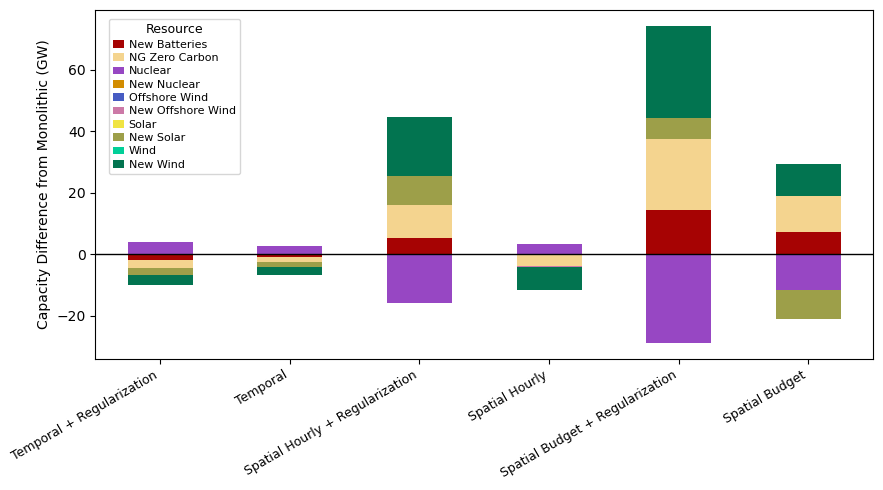

In [57]:
cap_diff_plot = cap_diff.T
colors = [fuel_color_map.get(fuel, "#999999") for fuel in cap_diff_plot.columns]

plt.figure(figsize=(9, 5))

cap_diff_plot.plot(
    kind="bar",
    stacked=True,
    color=colors,
    ax=plt.gca()
)

plt.axhline(0, color="black", linewidth=1)
plt.ylabel("Capacity Difference from Monolithic (GW)")
#plt.title("Generation Capacity Differences")
plt.xticks(
    rotation=30,      # slant labels
    ha="right",       # align nicely with ticks
    fontsize=9        # smaller text
)
plt.legend(
    title="Resource",
    loc="upper left",          # position in the axes
    bbox_to_anchor=(0.01, 0.99),  # slightly inset from top-left
    fontsize=8,                # legend text size
    title_fontsize=9,          # legend title size
    labelspacing=0.3,          # vertical spacing between entries
    handlelength=1.0,          # length of the color boxes
    handletextpad=0.4          # space between box and text
)

plt.tight_layout()
plt.savefig("capacity_diff.png")